## Telecom Churn Exploring Data Analysis

In [2]:
# importing all liabraires
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt;

In [3]:
df = pd.read_csv(r"../data/raw_telecom_churn.csv")

In [4]:
df.head(5)

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


In [5]:
df.columns

Index(['customer_id', 'telecom_partner', 'gender', 'age', 'state', 'city',
       'pincode', 'date_of_registration', 'num_dependents', 'estimated_salary',
       'calls_made', 'sms_sent', 'data_used', 'churn'],
      dtype='object')

In [6]:
df.shape

(243553, 14)

In [7]:
df.describe()

,customer_id,age,pincode,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
count,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000
mean,121777.000000,46.077609,549501.270541,1.997500,85021.137839,49.010548,23.945404,4993.186025,0.200478
std,70307.839393,16.444029,259808.860574,1.414941,37508.963233,29.453556,14.733575,2942.019547,0.400359
min,1.000000,18.000000,100006.000000,0.000000,20000.000000,-10.000000,-5.000000,-987.000000,0.000000
25%,60889.000000,32.000000,324586.000000,1.000000,52585.000000,24.000000,11.000000,2490.000000,0.000000
50%,121777.000000,46.000000,548112.000000,2.000000,84990.000000,49.000000,24.000000,4987.000000,0.000000
75%,182665.000000,60.000000,774994.000000,3.000000,117488.000000,74.000000,36.000000,7493.000000,0.000000
max,243553.000000,74.000000,999987.000000,4.000000,149999.000000,108.000000,53.000000,10991.000000,1.000000


In [8]:
df.isnull().sum() #checking missing values

customer_id             0
telecom_partner         0
gender                  0
age                     0
state                   0
city                    0
pincode                 0
date_of_registration    0
num_dependents          0
estimated_salary        0
calls_made              0
sms_sent                0
data_used               0
churn                   0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   customer_id           243553 non-null  int64 
 1   telecom_partner       243553 non-null  object
 2   gender                243553 non-null  object
 3   age                   243553 non-null  int64 
 4   state                 243553 non-null  object
 5   city                  243553 non-null  object
 6   pincode               243553 non-null  int64 
 7   date_of_registration  243553 non-null  object
 8   num_dependents        243553 non-null  int64 
 9   estimated_salary      243553 non-null  int64 
 10  calls_made            243553 non-null  int64 
 11  sms_sent              243553 non-null  int64 
 12  data_used             243553 non-null  int64 
 13  churn                 243553 non-null  int64 
dtypes: int64(9), object(5)
memory usage: 26.0+ MB


In [11]:
df.describe(include="all")

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
count,243553.000000,243553,243553,243553.000000,243553,243553,243553.000000,243553,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000
unique,NaN,4,2,NaN,28,6,NaN,1220,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Reliance Jio,M,NaN,Uttarakhand,Chennai,NaN,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,61123,145977,NaN,8856,40749,NaN,200,NaN,NaN,NaN,NaN,NaN,NaN
mean,121777.000000,NaN,NaN,46.077609,NaN,NaN,549501.270541,NaN,1.997500,85021.137839,49.010548,23.945404,4993.186025,0.200478
std,70307.839393,NaN,NaN,16.444029,NaN,NaN,259808.860574,NaN,1.414941,37508.963233,29.453556,14.733575,2942.019547,0.400359
min,1.000000,NaN,NaN,18.000000,NaN,NaN,100006.000000,NaN,0.000000,20000.000000,-10.000000,-5.000000,-987.000000,0.000000
25%,60889.000000,NaN,NaN,32.000000,NaN,NaN,324586.000000,NaN,1.000000,52585.000000,24.000000,11.000000,2490.000000,0.000000
50%,121777.000000,NaN,NaN,46.000000,NaN,NaN,548112.000000,NaN,2.000000,84990.000000,49.000000,24.000000,4987.000000,0.000000
75%,182665.000000,NaN,NaN,60.000000,NaN,NaN,774994.000000,NaN,3.000000,117488.000000,74.000000,36.000000,7493.000000,0.000000


In [12]:
print(df.columns.tolist()) #To verify that the columns are correctly named and there aren't accidental spaces

['customer_id', 'telecom_partner', 'gender', 'age', 'state', 'city', 'pincode', 'date_of_registration', 'num_dependents', 'estimated_salary', 'calls_made', 'sms_sent', 'data_used', 'churn']


In [13]:
df['customer_id'] = df['customer_id'].astype(str)
print(df['customer_id'].dtype)

object


In [14]:
df['date_of_registration'] = pd.to_datetime(df['date_of_registration'],errors='coerce')
print(df['date_of_registration'].dtype)



datetime64[ns]


In [15]:
df.describe()

,age,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
count,243553.000000,243553.000000,243553,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000
mean,46.077609,549501.270541,2021-09-01 00:00:00.354748416,1.997500,85021.137839,49.010548,23.945404,4993.186025,0.200478
min,18.000000,100006.000000,2020-01-01 00:00:00,0.000000,20000.000000,-10.000000,-5.000000,-987.000000,0.000000
25%,32.000000,324586.000000,2020-10-31 00:00:00,1.000000,52585.000000,24.000000,11.000000,2490.000000,0.000000
50%,46.000000,548112.000000,2021-09-01 00:00:00,2.000000,84990.000000,49.000000,24.000000,4987.000000,0.000000
75%,60.000000,774994.000000,2022-07-03 00:00:00,3.000000,117488.000000,74.000000,36.000000,7493.000000,0.000000
max,74.000000,999987.000000,2023-05-04 00:00:00,4.000000,149999.000000,108.000000,53.000000,10991.000000,1.000000
std,16.444029,259808.860574,NaN,1.414941,37508.963233,29.453556,14.733575,2942.019547,0.400359


In [16]:
print("Age:")
print(df['age'].min(), df['age'].max())

print("Dependents:")
print(df['num_dependents'].min(), df['num_dependents'].max())

print("Salary:")
print(df['estimated_salary'].min(), df['estimated_salary'].max())

print("Calls:")
print(df['calls_made'].min(), df['calls_made'].max())

print("SMS:")
print(df['sms_sent'].min(), df['sms_sent'].max())

print("Data:")
print(df['data_used'].min(), df['data_used'].max())

print("Churn:")
print(df['churn'].unique())

Age:
18 74
Dependents:
0 4
Salary:
20000 149999
Calls:
-10 108
SMS:
-5 53
Data:
-987 10991
Churn:
[0 1]


In [17]:
numeric_usage = [
    'calls_made',
    'sms_sent',
    'data_used'
]

for col in numeric_usage:
    print(col, (df[col] < 0).sum())

calls_made 6713
sms_sent 7375
data_used 6050


In [18]:
df[df['data_used']<0]

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
38,39,Reliance Jio,M,69,Gujarat,Chennai,712223,2020-01-01,1,87166,92,15,-790,0
69,70,Reliance Jio,M,28,Kerala,Chennai,520338,2020-01-01,2,34463,36,6,-492,0
72,73,BSNL,F,43,Uttarakhand,Delhi,554046,2020-01-01,4,101224,33,44,-73,0
87,88,Airtel,F,33,Himachal Pradesh,Kolkata,100889,2020-01-01,0,122987,78,4,-149,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243377,243378,Airtel,M,48,Arunachal Pradesh,Chennai,273303,2023-05-03,3,34942,47,39,-88,1
243434,243435,BSNL,M,31,Uttarakhand,Mumbai,585517,2023-05-03,2,143739,90,16,-403,0
243455,243456,BSNL,F,22,Chhattisgarh,Kolkata,371679,2023-05-03,4,107591,44,33,-459,0
243481,243482,Vodafone,F,61,Meghalaya,Chennai,964995,2023-05-03,3,59843,14,26,-529,0


### Check Categorial Data 

In [19]:
print(df['telecom_partner'].value_counts())

telecom_partner
Reliance Jio    61123
Airtel          60905
Vodafone        60802
BSNL            60723
Name: count, dtype: int64


In [20]:
print(df['state'].value_counts())

state
Uttarakhand          8856
Karnataka            8845
Maharashtra          8820
Madhya Pradesh       8817
Arunachal Pradesh    8757
Jharkhand            8755
Rajasthan            8750
Uttar Pradesh        8742
Haryana              8740
Kerala               8725
Tamil Nadu           8718
Odisha               8712
Goa                  8694
Telangana            8689
Sikkim               8689
Mizoram              8689
Meghalaya            8684
Himachal Pradesh     8682
Chhattisgarh         8677
Tripura              8660
Manipur              8651
Andhra Pradesh       8649
Bihar                8633
Punjab               8628
Gujarat              8610
West Bengal          8572
Nagaland             8562
Assam                8547
Name: count, dtype: int64


In [21]:
print(df['gender'].value_counts())

gender
M    145977
F     97576
Name: count, dtype: int64


In [22]:
print(df['city'].value_counts())

city
Chennai      40749
Hyderabad    40698
Kolkata      40661
Bangalore    40603
Delhi        40456
Mumbai       40386
Name: count, dtype: int64


In [23]:
print(df['state'].nunique())
print(df['city'].nunique())

28
6


In [24]:
df.columns

Index(['customer_id', 'telecom_partner', 'gender', 'age', 'state', 'city',
       'pincode', 'date_of_registration', 'num_dependents', 'estimated_salary',
       'calls_made', 'sms_sent', 'data_used', 'churn'],
      dtype='object')

In [25]:
df['estimated_salary'] = df['estimated_salary'].astype(float)
df['estimated_salary'].dtype

dtype('float64')

In [26]:
quality_report = pd.DataFrame({
    'column': df.columns,
    'data_type': df.dtypes.astype(str).values,
    'missing_values': df.isnull().sum().values,
    'missing_%': (
        df.isnull().sum().values / len(df) * 100
    ).round(2),
    'unique_values': df.nunique().values
})

quality_report

,column,data_type,missing_values,missing_%,unique_values
0,customer_id,object,0,0.0,243553
1,telecom_partner,object,0,0.0,4
2,gender,object,0,0.0,2
3,age,int64,0,0.0,57
4,state,object,0,0.0,28
5,city,object,0,0.0,6
6,pincode,int64,0,0.0,213442
7,date_of_registration,datetime64[ns],0,0.0,1220
8,num_dependents,int64,0,0.0,5
9,estimated_salary,float64,0,0.0,110032


In [30]:
churn_rate = df.groupby('telecom_partner')['churn'].mean()*100
print(churn_rate)

telecom_partner
Airtel          20.366144
BSNL            19.860679
Reliance Jio    20.015379
Vodafone        19.948357
Name: churn, dtype: float64


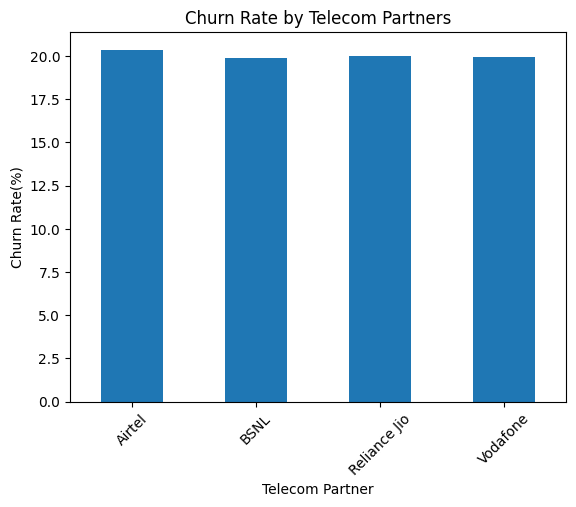

In [33]:
churn_rate.plot(kind='bar')

plt.title('Churn Rate by Telecom Partners')
plt.xlabel('Telecom Partner')
plt.ylabel('Churn Rate(%)')
plt.xticks(rotation=45)
plt.show()

#### Churn By Gender

In [ ]:
churn_distribution = df.groupby('gender').agg(
    total_customers=('customer_id', 'count'),
    churned_customers=('churn', 'sum')
)

print(churn_distribution)

        total_customers  churned_customers
gender                                    
F                 97576              19805
M                145977              29022


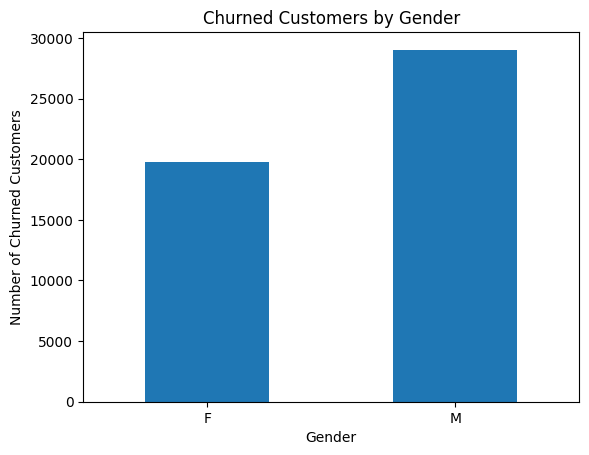

In [41]:
churned = df[df['churn'] == 1].groupby('gender')['customer_id'].count()

churned.plot(kind='bar')

plt.title('Churned Customers by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Churned Customers')
plt.xticks(rotation=0)
plt.show()

In [45]:
bins = [0, 25, 35, 45, 55, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56+']

df['age_group'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels
)

In [46]:
churn_rate_age = df.groupby(
    'age_group',
    observed=True
)['churn'].mean() * 100

print(churn_rate_age)

age_group
18-25    19.937695
26-35    20.058153
36-45    20.176323
46-55    19.960470
56+      20.067181
Name: churn, dtype: float64


In [27]:
import sqlite3

conn = sqlite3.connect(r"../database/telecom.db")

df.to_sql(
    "telecom",
    conn,
    if_exists="replace",
    index=False
)

conn.close()